In [1]:
import aml_pipeline_methods as aml
from sklearn import metrics

# Get the train/test data and normalize the feature set

In [2]:
#
# Read in the csv data
#
df_train, (df_test2017, df_test2018, df_test2019) = aml.pull_train_test_datasets()


#
# Replace NaN Values with Zero
#
df_train_o = aml.replace_any_nan_values(df_train)
df_test2017_o = aml.replace_any_nan_values(df_test2017)
df_test2018_o = aml.replace_any_nan_values(df_test2018)
df_test2019_o = aml.replace_any_nan_values(df_test2019)

#
# Get the features-label sets for train, validate and test
#
x_train, y_train = aml.get_features_labels_from_df(df_train_o)
x_test2017, y_test2017 = aml.get_features_labels_from_df(df_test2017_o)
x_test2018, y_test2018 = aml.get_features_labels_from_df(df_test2018_o)
x_test2019, y_test2019 = aml.get_features_labels_from_df(df_test2019_o)

#
# Normalize the feature sets
#
x_train_norm, x_test2017_norm = aml.normalize_datasets(x_train, x_test2017)
_, x_test2018_norm = aml.normalize_datasets(x_train, x_test2018)
_, x_test2019_norm = aml.normalize_datasets(x_train, x_test2019)

INFO: The shape of the feature set is (2891, 927)
INFO: The shape of the labels is (2891,)
INFO: The shape of the feature set is (193, 927)
INFO: The shape of the labels is (193,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)


# Determine how many features to use, either with PCA or selecting a custom dataset

In [3]:
N_PCA_COMPONENTS = 300
pca_, x_train_pca, x_test2017_pca = aml.transform_data_with_pca(N_PCA_COMPONENTS, x_train_norm, x_test2017_norm)

INFO: running PCA for 300 components



In [4]:
x_test2018_pca = pca_.transform(x_test2018_norm)
print(f'INFO: test 2018 pca shape -> {x_test2018_pca.shape}')

x_test2019_pca = pca_.transform(x_test2019_norm)
print(f'INFO: test 2019 pca shape -> {x_test2019_pca.shape}')

INFO: test 2018 pca shape -> (192, 300)
INFO: test 2019 pca shape -> (192, 300)


In [5]:
x_train_pca.var()

2.9624701450723254

In [6]:
x_train_norm.var()

1.0000000000000004

# Run SVM

In [8]:
#
# radial basis function kernel, default parameters, original feature set, no reduction
#
ikernel_type = 'rbf'
clf_rbf = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                    x_test2017_norm, y_test2017,
                    kernel_type=ikernel_type, C_in=1.0)
print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_norm, y_train)}')

y_pred2018 = clf_rbf.predict(x_test2018_norm)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

y_pred2019 = clf_rbf.predict(x_test2019_norm)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}')

Test Set Accuracy: 0.6580310880829016
INFO: The score for the SVM rbf classifier on the training set is 0.8989968868903494
Test Set Accuracy: 0.6302083333333334
Test Set Accuracy: 0.6145833333333334


In [9]:
#
# radial basis function kernel, default parameters, pca feature set
#
ikernel_type = 'rbf'
clf_rbf = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                    x_test2017_pca, y_test2017,
                    kernel_type=ikernel_type, C_in=1.0)
print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_pca, y_train)}')

y_pred2018 = clf_rbf.predict(x_test2018_pca)
print(f'2018 Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

y_pred2019 = clf_rbf.predict(x_test2019_pca)
print(f'2019 Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}')

Test Set Accuracy: 0.6580310880829016
INFO: The score for the SVM rbf classifier on the training set is 0.890003459010723
2018 Test Set Accuracy: 0.625
2019 Test Set Accuracy: 0.6302083333333334


# Vary the regualization parameter C

"The strength of the regularization is inversely proportional to C. Must be strictly positive. The penalty is a squared l2 penalty."

In [10]:
#
# radial basis function kernel, vary the regularization parameter 1 < C < 5, original feature set, no reduction
#
ikernel_type = 'rbf'
Cs = [1.3, 1.5, 1.9, 2.7, 4.3]
for C in Cs:
    print(f'INFO: Running {ikernel_type} with C = {C}')
    clf_rbf = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                        x_test2017_norm, y_test2017,
                        kernel_type=ikernel_type, C_in=C)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_norm, y_train)}')

    y_pred2018 = clf_rbf.predict(x_test2018_norm)
    print(f'2018 Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_rbf.predict(x_test2019_norm)
    print(f'2019 Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: Running rbf with C = 1.3
Test Set Accuracy: 0.6476683937823834
INFO: The score for the SVM rbf classifier on the training set is 0.9415427187824282
2018 Test Set Accuracy: 0.6197916666666666
2019 Test Set Accuracy: 0.609375

INFO: Running rbf with C = 1.5
Test Set Accuracy: 0.6528497409326425
INFO: The score for the SVM rbf classifier on the training set is 0.9605672777585611
2018 Test Set Accuracy: 0.6197916666666666
2019 Test Set Accuracy: 0.6145833333333334

INFO: Running rbf with C = 1.9
Test Set Accuracy: 0.6580310880829016
INFO: The score for the SVM rbf classifier on the training set is 0.9816672431684538
2018 Test Set Accuracy: 0.6197916666666666
2019 Test Set Accuracy: 0.6458333333333334

INFO: Running rbf with C = 2.7
Test Set Accuracy: 0.6787564766839378
INFO: The score for the SVM rbf classifier on the training set is 0.9979245935662401
2018 Test Set Accuracy: 0.6197916666666666
2019 Test Set Accuracy: 0.6354166666666666

INFO: Running rbf with C = 4.3
Test Set Accura

In [14]:
#
# radial basis function kernel, vary regularization parameter 1 < C < 5, pca feature set
#
ikernel_type = 'rbf'
Cs = [1.3, 1.5, 1.9, 2.7, 4.3]
for C in Cs:
    print(f'INFO: Running {ikernel_type} with C = {C}')
    clf_rbf = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                        x_test2017_pca, y_test2017,
                        kernel_type=ikernel_type, C_in=C)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_pca, y_train)}')

    y_pred2018 = clf_rbf.predict(x_test2018_pca)
    print(f'2018 Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_rbf.predict(x_test2019_pca)
    print(f'2019 Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: Running rbf with C = 1.3
Test Set Accuracy: 0.6735751295336787
INFO: The score for the SVM rbf classifier on the training set is 0.9322033898305084
2018 Test Set Accuracy: 0.625
2019 Test Set Accuracy: 0.609375

INFO: Running rbf with C = 1.5
Test Set Accuracy: 0.6735751295336787
INFO: The score for the SVM rbf classifier on the training set is 0.9522656520235213
2018 Test Set Accuracy: 0.6302083333333334
2019 Test Set Accuracy: 0.609375

INFO: Running rbf with C = 1.9
Test Set Accuracy: 0.6580310880829016
INFO: The score for the SVM rbf classifier on the training set is 0.975441023867174
2018 Test Set Accuracy: 0.6458333333333334
2019 Test Set Accuracy: 0.6302083333333334

INFO: Running rbf with C = 2.7
Test Set Accuracy: 0.6632124352331606
INFO: The score for the SVM rbf classifier on the training set is 0.9951573849878934
2018 Test Set Accuracy: 0.640625
2019 Test Set Accuracy: 0.6302083333333334

INFO: Running rbf with C = 4.3
Test Set Accuracy: 0.6528497409326425
INFO: The s

In [13]:
#
# radial basis function kernel, vary the regularization parameter 0 < C <= 0.1, original feature set, no reduction
#
ikernel_type = 'rbf'
Cs = [0.1/(10**i) for i in range(1,6)]
for C in Cs:
    print(f'INFO: Running {ikernel_type} with C = {C}')
    clf_rbf = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                        x_test2017_norm, y_test2017,
                        kernel_type=ikernel_type, C_in=C)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_norm, y_train)}')

    y_pred2018 = clf_rbf.predict(x_test2018_norm)
    print(f'2018 Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_rbf.predict(x_test2019_norm)
    print(f'2019 Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: Running rbf with C = 0.01
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 0.001
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 0.0001
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1e-05
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1e-06
Test Set Accuracy: 0.5595854922279793
I

In [15]:
#
# radial basis function kernel, vary regularization parameter 0 < C <= 0.1, pca feature set
#
ikernel_type = 'rbf'
Cs = [0.1/(10**i) for i in range(1,6)]
for C in Cs:
    print(f'INFO: Running {ikernel_type} with C = {C}')
    clf_rbf = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                        x_test2017_pca, y_test2017,
                        kernel_type=ikernel_type, C_in=C)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_pca, y_train)}')

    y_pred2018 = clf_rbf.predict(x_test2018_pca)
    print(f'2018 Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_rbf.predict(x_test2019_pca)
    print(f'2019 Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: Running rbf with C = 0.01
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 0.001
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 0.0001
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1e-05
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1e-06
Test Set Accuracy: 0.5595854922279793
I

# Try different kernels

In [17]:
#
# linear function kernel, default parameters, original feature set, no reduction
#
ikernel_type = 'linear'
clf_linear = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                    x_test2017_norm, y_test2017,
                    kernel_type=ikernel_type, C_in=1.0)
print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_linear.score(x_train_norm, y_train)}')

y_pred2018 = clf_linear.predict(x_test2018_norm)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

y_pred2019 = clf_linear.predict(x_test2019_norm)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}')

Test Set Accuracy: 0.5233160621761658
INFO: The score for the SVM linear classifier on the training set is 0.8253199584918713
Test Set Accuracy: 0.53125
Test Set Accuracy: 0.6041666666666666


In [19]:
# linear function kernel, default parameters, pca feature set
#
ikernel_type = 'linear'
clf_linear = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                    x_test2017_pca, y_test2017,
                    kernel_type=ikernel_type, C_in=1.0)
print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_linear.score(x_train_pca, y_train)}')

y_pred2018 = clf_linear.predict(x_test2018_pca)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

y_pred2019 = clf_linear.predict(x_test2019_pca)
print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}')

Test Set Accuracy: 0.6424870466321243
INFO: The score for the SVM linear classifier on the training set is 0.716015219647181
Test Set Accuracy: 0.6041666666666666
Test Set Accuracy: 0.6510416666666666


In [20]:
#
# polynomial function kernel, vary polynomial degree parameter, original feature set, no reduction
#
ikernel_type = 'poly'
degree_set = (3, 5, 7, 10)
for idegree in degree_set:
    print(f'INFO: running polynomial with degree = {idegree}')
    clf_poly = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                        x_test2017_norm, y_test2017,
                        kernel_type=ikernel_type, C_in=1.0, degree_in=idegree)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_poly.score(x_train_norm, y_train)}')

    y_pred2018 = clf_poly.predict(x_test2018_norm)
    print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_poly.predict(x_test2019_norm)
    print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: running polynomial with degree = 3
Test Set Accuracy: 0.5803108808290155
INFO: The score for the SVM poly classifier on the training set is 0.9619508820477344
Test Set Accuracy: 0.6302083333333334
Test Set Accuracy: 0.5625

INFO: running polynomial with degree = 5
Test Set Accuracy: 0.5647668393782384
INFO: The score for the SVM poly classifier on the training set is 0.890003459010723
Test Set Accuracy: 0.609375
Test Set Accuracy: 0.53125

INFO: running polynomial with degree = 7
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM poly classifier on the training set is 0.8412314078173643
Test Set Accuracy: 0.6041666666666666
Test Set Accuracy: 0.53125

INFO: running polynomial with degree = 10
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM poly classifier on the training set is 0.8062953995157385
Test Set Accuracy: 0.6041666666666666
Test Set Accuracy: 0.53125



In [21]:
#
# polynomial function kernel, vary polynomial degree parameter, pca feature set
#
ikernel_type = 'poly'
degree_set = (3, 5, 7, 10)
for idegree in degree_set:
    print(f'INFO: running polynomial with degree = {idegree}')
    clf_poly = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                        x_test2017_pca, y_test2017,
                        kernel_type=ikernel_type, C_in=1.0, degree_in=idegree)
    print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_poly.score(x_train_pca, y_train)}')

    y_pred2018 = clf_poly.predict(x_test2018_pca)
    print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2018, y_pred2018)}')

    y_pred2019 = clf_poly.predict(x_test2019_pca)
    print(f'Test Set Accuracy: {metrics.accuracy_score(y_test2019, y_pred2019)}\n')

INFO: running polynomial with degree = 3
Test Set Accuracy: 0.5803108808290155
INFO: The score for the SVM poly classifier on the training set is 0.9539951573849879
Test Set Accuracy: 0.625
Test Set Accuracy: 0.5729166666666666

INFO: running polynomial with degree = 5
Test Set Accuracy: 0.5647668393782384
INFO: The score for the SVM poly classifier on the training set is 0.8851608439986164
Test Set Accuracy: 0.6145833333333334
Test Set Accuracy: 0.546875

INFO: running polynomial with degree = 7
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM poly classifier on the training set is 0.8363887928052577
Test Set Accuracy: 0.6041666666666666
Test Set Accuracy: 0.53125

INFO: running polynomial with degree = 10
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM poly classifier on the training set is 0.8017986855759253
Test Set Accuracy: 0.6041666666666666
Test Set Accuracy: 0.53125



# Conclusion: use rbf kernel with regularization C between [1.3, 4.7]

In [22]:
#
# create master script to evaluate algorithm
#

#
# Read in the csv data
#
df_train, (df_test2017, df_test2018, df_test2019) = aml.pull_train_test_datasets()


#
# Replace NaN Values with Zero
#
df_train_o = aml.replace_any_nan_values(df_train)
df_test2017_o = aml.replace_any_nan_values(df_test2017)
df_test2018_o = aml.replace_any_nan_values(df_test2018)
df_test2019_o = aml.replace_any_nan_values(df_test2019)

#
# Get the features-label sets for train, validate and test
#
x_train, y_train = aml.get_features_labels_from_df(df_train_o)
x_test2017, y_test2017 = aml.get_features_labels_from_df(df_test2017_o)
x_test2018, y_test2018 = aml.get_features_labels_from_df(df_test2018_o)
x_test2019, y_test2019 = aml.get_features_labels_from_df(df_test2019_o)

#
# Normalize the feature sets
#
x_train_norm, x_test2017_norm = aml.normalize_datasets(x_train, x_test2017)
_, x_test2018_norm = aml.normalize_datasets(x_train, x_test2018)
_, x_test2019_norm = aml.normalize_datasets(x_train, x_test2019)

N_PCA_COMPONENTS = list(range(150, 350, 50))

best_pca = dict()
bestScore_pca = 0

for N in N_PCA_COMPONENTS:
    pca_, x_train_pca, x_test2017_pca = aml.transform_data_with_pca(N, x_train_norm, x_test2017_norm)
    
    x_test2018_pca = pca_.transform(x_test2018_norm)
    print(f'INFO: test 2018 pca shape -> {x_test2018_pca.shape}')

    x_test2019_pca = pca_.transform(x_test2019_norm)
    print(f'INFO: test 2019 pca shape -> {x_test2019_pca.shape}')
    
    #
    # radial basis function kernel, vary regularization parameter 1 < C < 5, pca feature set
    #
    ikernel_type = 'rbf'
    Cs = [1.3, 1.5, 1.9, 2.7, 4.3]
    gammas = [1 / (10**i) for i in range(0, 7)]
    for C in Cs:
        for gam in gammas:
            print(f'INFO: Running {ikernel_type} with C = {C}, gamma = {gam}')
            clf_rbf = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                                x_test2017_pca, y_test2017,
                                kernel_type=ikernel_type, C_in=C, gamma_in=gam)
            print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_pca, y_train)}')

            y_pred2018 = clf_rbf.predict(x_test2018_pca)
            score_2018 = metrics.accuracy_score(y_test2018, y_pred2018)
            print(f'2018 Test Set Accuracy: {score_2018}')

            y_pred2019 = clf_rbf.predict(x_test2019_pca)
            score_2019 = metrics.accuracy_score(y_test2019, y_pred2019)
            print(f'2019 Test Set Accuracy: {score_2019}\n')

            y_pred2017 = clf_rbf.predict(x_test2017_pca)
            score_2017 = metrics.accuracy_score(y_test2017, y_pred2017)

            score_avg = (score_2017 + score_2018 + score_2019) / 3.0
            if score_avg > bestScore_pca:
                bestScore_pca = score_avg
                best_pca['C'] = C
                best_pca['gamma'] = gam
                best_pca['N_PCA_Components'] = N
                best_pca['2017_score'] = score_2017
                best_pca['2018_score'] = score_2018
                best_pca['2019_score'] = score_2019
                best_pca['avg_score'] = score_avg

print('\n' + '*'*80 + '\n')

#
# radial basis function kernel, vary the regularization parameter 1 < C < 5, original feature set, no reduction
#
best_norm = dict()
bestScore_norm = 0

ikernel_type = 'rbf'
Cs = [1.3, 1.5, 1.9, 2.7, 4.3]
gammas = [1 / (10**i) for i in range(0, 7)]
for C in Cs:
    for gam in gammas:
        print(f'INFO: Running {ikernel_type} with C = {C}, gamma = {gam}')
        clf_rbf = aml.run_svm_nfl_predict(x_train_norm, y_train, 
                            x_test2017_norm, y_test2017,
                            kernel_type=ikernel_type, C_in=C, gamma_in=gam)
        print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_norm, y_train)}')

        y_pred2018 = clf_rbf.predict(x_test2018_norm)
        score_2018 = metrics.accuracy_score(y_test2018, y_pred2018)
        print(f'2018 Test Set Accuracy: {score_2018}')

        y_pred2019 = clf_rbf.predict(x_test2019_norm)
        score_2019 = metrics.accuracy_score(y_test2019, y_pred2019)
        print(f'2019 Test Set Accuracy: {score_2019}\n')

        y_pred2017 = clf_rbf.predict(x_test2017_norm)
        score_2017 = metrics.accuracy_score(y_test2017, y_pred2017)

        score_avg = (score_2017 + score_2018 + score_2019) / 3.0
        if score_avg > bestScore_norm:
            bestScore_norm = score_avg
            best_norm['C'] = C
            best_norm['gamma'] = gam
            best_norm['2017_score'] = score_2017
            best_norm['2018_score'] = score_2018
            best_norm['2019_score'] = score_2019
            best_norm['avg_score'] = score_avg

print(f'INFO: The best PCA version is,')
for k,v in best_pca.items():
    print(f'{k}: {v}')

print(f'\nINFO: The best original version is,')
for k,v in best_norm.items():
    print(f'{k}: {v}')

INFO: The shape of the feature set is (2891, 927)
INFO: The shape of the labels is (2891,)
INFO: The shape of the feature set is (193, 927)
INFO: The shape of the labels is (193,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)
INFO: running PCA for 150 components

INFO: test 2018 pca shape -> (192, 150)
INFO: test 2019 pca shape -> (192, 150)
INFO: Running rbf with C = 1.3, gamma = 1.0
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1.3, gamma = 0.1
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1.3, gamma = 0.01
Test Set Accuracy: 0.55

Test Set Accuracy: 0.6113989637305699
INFO: The score for the SVM rbf classifier on the training set is 0.6409546869595296
2018 Test Set Accuracy: 0.6458333333333334
2019 Test Set Accuracy: 0.578125

INFO: Running rbf with C = 4.3, gamma = 1e-06
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: running PCA for 200 components

INFO: test 2018 pca shape -> (192, 200)
INFO: test 2019 pca shape -> (192, 200)
INFO: Running rbf with C = 1.3, gamma = 1.0
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 1.3, gamma = 0.1
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set 

Test Set Accuracy: 0.6476683937823834
INFO: The score for the SVM rbf classifier on the training set is 0.7021791767554479
2018 Test Set Accuracy: 0.6302083333333334
2019 Test Set Accuracy: 0.640625

INFO: Running rbf with C = 4.3, gamma = 1e-05
Test Set Accuracy: 0.6062176165803109
INFO: The score for the SVM rbf classifier on the training set is 0.6440677966101694
2018 Test Set Accuracy: 0.640625
2019 Test Set Accuracy: 0.5833333333333334

INFO: Running rbf with C = 4.3, gamma = 1e-06
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: running PCA for 250 components

INFO: test 2018 pca shape -> (192, 250)
INFO: test 2019 pca shape -> (192, 250)
INFO: Running rbf with C = 1.3, gamma = 1.0
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666

Test Set Accuracy: 0.6528497409326425
INFO: The score for the SVM rbf classifier on the training set is 0.9986163957108267
2018 Test Set Accuracy: 0.609375
2019 Test Set Accuracy: 0.640625

INFO: Running rbf with C = 4.3, gamma = 0.0001
Test Set Accuracy: 0.6632124352331606
INFO: The score for the SVM rbf classifier on the training set is 0.7077135939121412
2018 Test Set Accuracy: 0.6302083333333334
2019 Test Set Accuracy: 0.65625

INFO: Running rbf with C = 4.3, gamma = 1e-05
Test Set Accuracy: 0.6113989637305699
INFO: The score for the SVM rbf classifier on the training set is 0.6457973019716361
2018 Test Set Accuracy: 0.640625
2019 Test Set Accuracy: 0.5833333333333334

INFO: Running rbf with C = 4.3, gamma = 1e-06
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 0.5672777585610516
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: running PCA for 300 components

INFO: test 2018 pca shape -> (192, 

Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 4.3, gamma = 0.001
Test Set Accuracy: 0.6787564766839378
INFO: The score for the SVM rbf classifier on the training set is 0.99896229678312
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.625

INFO: Running rbf with C = 4.3, gamma = 0.0001
Test Set Accuracy: 0.6528497409326425
INFO: The score for the SVM rbf classifier on the training set is 0.710826703562781
2018 Test Set Accuracy: 0.6354166666666666
2019 Test Set Accuracy: 0.640625

INFO: Running rbf with C = 4.3, gamma = 1e-05
Test Set Accuracy: 0.6062176165803109
INFO: The score for the SVM rbf classifier on the training set is 0.6451054998270495
2018 Test Set Accuracy: 0.6458333333333334
2019 Test Set Accuracy: 0.59375

INFO: Running rbf with C = 4.3, gamma = 1e-06
Test Set Accuracy: 0.5595854922279793


INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 4.3, gamma = 0.01
Test Set Accuracy: 0.5595854922279793
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.53125

INFO: Running rbf with C = 4.3, gamma = 0.001
Test Set Accuracy: 0.6632124352331606
INFO: The score for the SVM rbf classifier on the training set is 1.0
2018 Test Set Accuracy: 0.59375
2019 Test Set Accuracy: 0.6302083333333334

INFO: Running rbf with C = 4.3, gamma = 0.0001
Test Set Accuracy: 0.6632124352331606
INFO: The score for the SVM rbf classifier on the training set is 0.7232791421653407
2018 Test Set Accuracy: 0.6041666666666666
2019 Test Set Accuracy: 0.65625

INFO: Running rbf with C = 4.3, gamma = 1e-05
Test Set Accuracy: 0.5958549222797928
INFO: The score for the SVM rbf classifier on the training set is

In [40]:
(50.78 + 43.23 + 48.44) / 3.0

47.48333333333333

# Determine the point spead bet accuracy

In [39]:
import os
import pandas as pd

stats_dir = r'C:\Users\cocod\Work\Repos\NFL_stats_tracker\stats'

# use the best classifier parameters
N = 300
C = 2.7
gamma = 0.001
ikernel_type = 'rbf'

df_train, (df_test2017, df_test2018, df_test2019) = aml.pull_train_test_datasets()


#
# Replace NaN Values with Zero
#
df_train_o = aml.replace_any_nan_values(df_train)
df_test2017_o = aml.replace_any_nan_values(df_test2017)
df_test2018_o = aml.replace_any_nan_values(df_test2018)
df_test2019_o = aml.replace_any_nan_values(df_test2019)

#
# Get the features-label sets for train, validate and test
#
x_train, y_train = aml.get_features_labels_from_df(df_train_o)
x_test2017, y_test2017 = aml.get_features_labels_from_df(df_test2017_o)
x_test2018, y_test2018 = aml.get_features_labels_from_df(df_test2018_o)
x_test2019, y_test2019 = aml.get_features_labels_from_df(df_test2019_o)

#
# Normalize the feature sets
#
x_train_norm, x_test2017_norm = aml.normalize_datasets(x_train, x_test2017)
_, x_test2018_norm = aml.normalize_datasets(x_train, x_test2018)
_, x_test2019_norm = aml.normalize_datasets(x_train, x_test2019)

# 
# Run PCA
#
pca_, x_train_pca, x_test2017_pca = aml.transform_data_with_pca(N, x_train_norm, x_test2017_norm)
    
x_test2018_pca = pca_.transform(x_test2018_norm)
print(f'INFO: test 2018 pca shape -> {x_test2018_pca.shape}')

x_test2019_pca = pca_.transform(x_test2019_norm)
print(f'INFO: test 2019 pca shape -> {x_test2019_pca.shape}')

# train the classifier
clf_rbf = aml.run_svm_nfl_predict(x_train_pca, y_train, 
                    x_test2017_pca, y_test2017,
                    kernel_type=ikernel_type, C_in=C, gamma_in=gamma)
print(f'INFO: The score for the SVM {ikernel_type} classifier on the training set is {clf_rbf.score(x_train_pca, y_train)}')

y_pred2018 = clf_rbf.predict(x_test2018_pca)
score_2018 = metrics.accuracy_score(y_test2018, y_pred2018)
print(f'2018 Test Set Accuracy: {score_2018}')

y_pred2019 = clf_rbf.predict(x_test2019_pca)
score_2019 = metrics.accuracy_score(y_test2019, y_pred2019)
print(f'2019 Test Set Accuracy: {score_2019}\n')


test_year_sets = [
    (2017, x_test2017_pca, y_test2017, df_test2017),
    (2018, x_test2018_pca, y_test2018, df_test2018),
    (2019, x_test2019_pca, y_test2019, df_test2019)
]
for year, x_test_pca, y_test, df_test in test_year_sets:
    # Determine the accuracy prediction for point spread bets
    total_wins_wts = 0

    for ix in range(len(x_test_pca)):
        X_i = x_test_pca[ix, :]
        y_pred = clf_rbf.predict(X_i.reshape((1,N)))

        if 0 == y_pred:
            # get the spread for the away team
            team = df_test.iloc[ix]['Away Team']
        else:
            # get the spread for the home team
            team = df_test.iloc[ix]['Home Team']

        week_n = df_test.iloc[ix]['Week']

        # open team dataframe
        team_csv = os.path.join(stats_dir, f'{year}', 'team_season_stats', f'{team}_season_{year}.csv')
        df = pd.read_csv(team_csv)

        mask = df['Week'] == week_n
        point_spread = int(df[mask]['GI Vegas Line'].values[0])

        team_score = int(df[mask]['LS Final Score'].values[0])
        opponent_score = int(df[mask]['LS Total Points Gave Up'])

        y_true = y_test[ix]

        if point_spread > 0:
            # underdog team
            if y_pred == y_true:
                # underdog won the game so won the bet
                total_wins_wts += 1
            else:
                # check how much lost by
                diff = abs(team_score - opponent_score)
                if diff < point_spread:
                    total_wins_wts += 1
        else: # point_spread <= 0
            # favored team
            if y_pred == y_true:
                # the favored team won the game, check the point spread was met
                diff = abs(team_score - opponent_score)
                if diff > abs(point_spread):
                    # the point spread was met
                    total_wins_wts += 1

    wts_win_rate = total_wins_wts / len(x_test_pca)
    print(f'Year {year} - {wts_win_rate*100:.2f}%')

INFO: The shape of the feature set is (2891, 927)
INFO: The shape of the labels is (2891,)
INFO: The shape of the feature set is (193, 927)
INFO: The shape of the labels is (193,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)
INFO: The shape of the feature set is (192, 927)
INFO: The shape of the labels is (192,)
INFO: running PCA for 300 components

INFO: test 2018 pca shape -> (192, 300)
INFO: test 2019 pca shape -> (192, 300)
Test Set Accuracy: 0.6683937823834197
INFO: The score for the SVM rbf classifier on the training set is 0.9878934624697336
2018 Test Set Accuracy: 0.625
2019 Test Set Accuracy: 0.6302083333333334

Year 2017 - 50.78%
Year 2018 - 43.23%
Year 2019 - 48.44%


In [33]:
X_i.reshape((1,300)).shape

(1, 300)

In [28]:
mask1 = df_test2017['Game Index'] == 0
mask2 = df_test2017['Week'] == 4
mask = mask1 & mask2
df_test2017[mask]['Home Team'].values[0]

'CHI'

C:\Users\cocod\anaconda3\lib\site-packages\sklearn\svm\_base.py:976: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


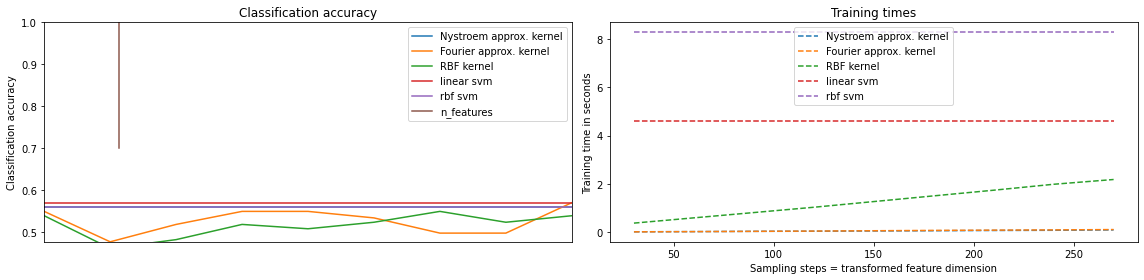

In [21]:
# Author: Gael Varoquaux <gael dot varoquaux at normalesup dot org>
#         Andreas Mueller <amueller@ais.uni-bonn.de>
# License: BSD 3 clause

# Standard scientific Python imports
from time import time

import matplotlib.pyplot as plt
import numpy as np

# Import datasets, classifiers and performance metrics
from sklearn import datasets, pipeline, svm
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem, RBFSampler

# The digits dataset
#digits = datasets.load_digits(n_class=9)


#n_samples = len(digits.data)
#data = digits.data / 16.0
#data -= data.mean(axis=0)

# We learn the digits on the first half of the digits
#data_train, targets_train = (data[: n_samples // 2], digits.target[: n_samples // 2])


# Now predict the value of the digit on the second half:
#data_test, targets_test = (data[n_samples // 2 :], digits.target[n_samples // 2 :])
# data_test = scaler.transform(data_test)

# Create a classifier: a support vector classifier
kernel_svm = svm.SVC(gamma=0.2)
#linear_svm = svm.LinearSVC(dual="auto", random_state=42)
linear_svm = svm.LinearSVC(random_state=42)

# create pipeline from kernel approximation
# and linear svm
feature_map_fourier = RBFSampler(gamma=0.2, random_state=1)
feature_map_nystroem = Nystroem(gamma=0.2, random_state=1)
fourier_approx_svm = pipeline.Pipeline(
    [
        ("feature_map", feature_map_fourier),
        #("svm", svm.LinearSVC(dual="auto", random_state=42)),
        ("svm", svm.LinearSVC(random_state=42)),
        #('svm_rbf', svm.SVC(gamma=0.2))
    ]
)

nystroem_approx_svm = pipeline.Pipeline(
    [
        ("feature_map", feature_map_nystroem),
        #("svm", svm.LinearSVC(dual="auto", random_state=42)),
        ("svm", svm.LinearSVC(random_state=42)),
    ]
)

rbf_approx_svm = pipeline.Pipeline(
    [
        ("feature_map", feature_map_fourier),
        ("svm_rbf", svm.SVC(C=2.7))
    ]
)

# fit and predict using linear and kernel svm:

kernel_svm_time = time()
#kernel_svm.fit(data_train, targets_train)
kernel_svm.fit(x_train_norm, y_train)
#kernel_svm_score = kernel_svm.score(data_test, targets_test)
kernel_svm_score = kernel_svm.score(x_test2017_norm, y_test2017)
kernel_svm_time = time() - kernel_svm_time

linear_svm_time = time()
#linear_svm.fit(data_train, targets_train)
linear_svm.fit(x_train_norm, y_train)
#linear_svm_score = linear_svm.score(data_test, targets_test)
linear_svm_score = linear_svm.score(x_test2017_norm, y_test2017)
linear_svm_time = time() - linear_svm_time

sample_sizes = 30 * np.arange(1, 10)
fourier_scores = []
nystroem_scores = []
fourier_times = []
nystroem_times = []

rbf_scores = []
rbf_times = []

for D in sample_sizes:
    fourier_approx_svm.set_params(feature_map__n_components=D)
    nystroem_approx_svm.set_params(feature_map__n_components=D)
    rbf_approx_svm.set_params(feature_map__n_components=D)
    
    start = time()
    #nystroem_approx_svm.fit(data_train, targets_train)
    nystroem_approx_svm.fit(x_train_norm, y_train)
    nystroem_times.append(time() - start)

    start = time()
    rbf_approx_svm.fit(x_train_norm, y_train)
    rbf_times.append(time() - start)
    
    start = time()
    #fourier_approx_svm.fit(data_train, targets_train)
    fourier_approx_svm.fit(x_train_norm, y_train)
    fourier_times.append(time() - start)

    #fourier_score = fourier_approx_svm.score(data_test, targets_test)
    fourier_score = fourier_approx_svm.score(x_test2017_norm, y_test2017)
    #nystroem_score = nystroem_approx_svm.score(data_test, targets_test)
    nystroem_score = nystroem_approx_svm.score(x_test2017_norm, y_test2017)
    nystroem_scores.append(nystroem_score)
    fourier_scores.append(fourier_score)
    
    rbf_score = rbf_approx_svm.score(x_test2017_norm, y_test2017)
    rbf_scores.append(rbf_score)

# plot the results:
plt.figure(figsize=(16, 4))
accuracy = plt.subplot(121)
# second y axis for timings
timescale = plt.subplot(122)

accuracy.plot(sample_sizes, nystroem_scores, label="Nystroem approx. kernel")
timescale.plot(sample_sizes, nystroem_times, "--", label="Nystroem approx. kernel")

accuracy.plot(sample_sizes, fourier_scores, label="Fourier approx. kernel")
timescale.plot(sample_sizes, fourier_times, "--", label="Fourier approx. kernel")

accuracy.plot(sample_sizes, rbf_scores, label="RBF kernel")
timescale.plot(sample_sizes, rbf_times, "--", label="RBF kernel")

# horizontal lines for exact rbf and linear kernels:
accuracy.plot(
    [sample_sizes[0], sample_sizes[-1]],
    [linear_svm_score, linear_svm_score],
    label="linear svm",
)
timescale.plot(
    [sample_sizes[0], sample_sizes[-1]],
    [linear_svm_time, linear_svm_time],
    "--",
    label="linear svm",
)

accuracy.plot(
    [sample_sizes[0], sample_sizes[-1]],
    [kernel_svm_score, kernel_svm_score],
    label="rbf svm",
)
timescale.plot(
    [sample_sizes[0], sample_sizes[-1]],
    [kernel_svm_time, kernel_svm_time],
    "--",
    label="rbf svm",
)

# vertical line for dataset dimensionality = 64
accuracy.plot([64, 64], [0.7, 1], label="n_features")

# legends and labels
accuracy.set_title("Classification accuracy")
timescale.set_title("Training times")
accuracy.set_xlim(sample_sizes[0], sample_sizes[-1])
accuracy.set_xticks(())
accuracy.set_ylim(np.min(fourier_scores), 1)
timescale.set_xlabel("Sampling steps = transformed feature dimension")
accuracy.set_ylabel("Classification accuracy")
timescale.set_ylabel("Training time in seconds")
accuracy.legend(loc="best")
timescale.legend(loc="best")
plt.tight_layout()
plt.show()

In [24]:
df_train.iloc[0]['Home Team']

'MIA'